## Task 2

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio


In [97]:
data = sio.loadmat("Signals_task2/Signal3.mat")
r = data['R'].flatten()

# System parameters
fs = 44100
fc = 4000
N  = 100
Ns = len(r) // N

# Pulse shape
p = np.sin(np.pi * np.arange(N) / N)

# Carrier waves
n     = np.arange(Ns * N)
cos_c = np.cos(2 * np.pi * fc * n / fs)
sin_c = np.sin(2 * np.pi * fc * n / fs)


## Down conversion

In [98]:
n_full = np.arange(len(r))
r_I =  2 * r * np.cos(2 * np.pi * fc * n_full / fs)
r_Q = -2 * r * np.sin(2 * np.pi * fc * n_full / fs)

## Synchronization

In [99]:
# Synchronization: cross-correlate r with known pilot passband waveform
# Pilot symbol (2+2j): passband = p[n]*(2*cos(2pi*fc*n/fs) - 2*sin(2pi*fc*n/fs))
n_p = np.arange(N)
p_pulse = np.sin(np.pi * n_p / N)
pilot_pb = 2*p_pulse*np.cos(2*np.pi*fc*n_p/fs) - 2*p_pulse*np.sin(2*np.pi*fc*n_p/fs)

abs_corr = np.abs(np.correlate(r, pilot_pb, mode='valid'))

# First pilot peak
tau_start = np.argmax(abs_corr)

# Second pilot: search away from first peak
search = abs_corr.copy()
search[max(0, tau_start - N) : tau_start + 10*N] = 0
tau_end = np.argmax(search)

Ns_packet = (tau_end - tau_start) // N + 1
print(f'Pilot 1 at sample {tau_start}, Pilot 2 at sample {tau_end}')
print(f'Packet symbols (incl. pilots): {Ns_packet}')


Pilot 1 at sample 113843, Pilot 2 at sample 138142
Packet symbols (incl. pilots): 243


## Channel Estimation

In [100]:
yI = r_I[tau_start : tau_start + Ns_packet*N].reshape(Ns_packet, N) @ p
yQ = r_Q[tau_start : tau_start + Ns_packet*N].reshape(Ns_packet, N) @ p
y  = yI + 1j * yQ

h_start  = y[0]  / (2 + 2j)
h_end    = y[-1] / (2 + 2j)
k        = np.arange(Ns_packet)
h_interp = h_start + (h_end - h_start) * k / (Ns_packet - 1)

print(f'h_start = {h_start:.3f}')
print(f'h_end   = {h_end:.3f}')

h_start = -17372.370-16590.199j
h_end   = -8567.231-11176.117j


## Pilot removal

In [101]:
y_data = y[1:-1]
h_data = h_interp[1:-1]

## Sampling and channel equalization

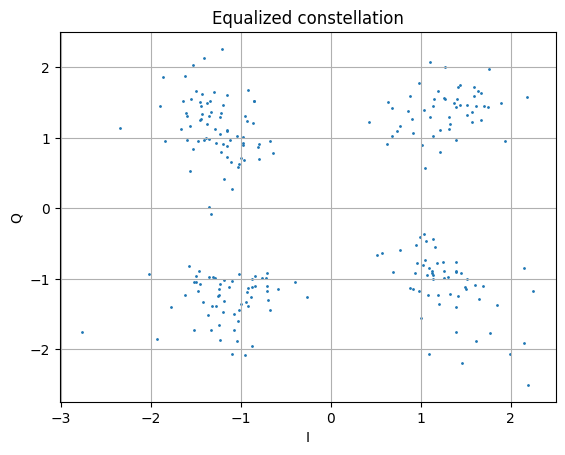

In [102]:
y_eq = y_data / h_data

plt.scatter(y_eq.real, y_eq.imag, s=1)
plt.xlabel('I'); plt.ylabel('Q')
plt.title('Equalized constellation')
plt.grid(); plt.show()

## Decoding

In [103]:
bits = []
for sym in y_eq:
    bits.append('1' if sym.real < 0 else '0')
    bits.append('1' if sym.imag < 0 else '0')

bitstr = ''.join(bits)
n_bits  = (len(bitstr) // 7) * 7
message = ''.join(chr(int(bitstr[j:j+7], 2)) for j in range(0, n_bits, 7))
print(f'Message: {message}')

Message: Turbo Codes were invented by Berrou, Glavieux and Thi4imajshima 1993


## **Answer:**

The final message is:
- **Turbo Codes were invented by Berrou, Glavieux and Thi4imajshima 1993**
- 
- Whether or not the "4" in Thitimajshima is an actual error or a clever pun from the teacher is up for debate.